# 🧬 Dedup & Survivorship Pipeline

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/dedup-pipeline/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/dedup-pipeline/demo.ipynb)

**Pain point:** *"Duplicate records everywhere."*

The full MDM (master data management) loop in miniature: normalize messy variants so they collide, cluster by match keys, then merge each cluster into a **golden record** using per-field survivorship rules — with provenance showing exactly which source won each field and why.

**What this notebook covers:**
1. The pipeline — normalization, clustering, survivorship rules
2. Deduping 99 messy customer rows from 3 systems
3. Inspecting a merged cluster field by field
4. Visualizing clusters and source wins
5. Try your own rules


## Step 1 — The pipeline

Three stages:
- **Normalize** — `Ana.Li@GMAIL.com`, `analI@gmail.com` and `ana.li@gmail.com` must collide: lowercase, strip Gmail dots/plus-tags, keep last 10 phone digits. Normalized keys are for *matching only* — the golden record keeps a real value.
- **Cluster** — rows whose normalized `(email, phone)` pair matches form one entity.
- **Survivorship** — per field, a rule picks the winner: `most_recent` (freshest timestamp), `source_priority` (CRM beats web beats import), `longest_value` (fullest address), `most_complete_record` (trust the row that knows the most). Every choice is logged to a provenance table — the difference between a merge you can audit and a merge you have to trust.


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import pandas as pd

# --- Normalization: make different spellings of the same entity collide -------

def normalize_email(v: object) -> Optional[str]:
    if pd.isna(v) or not str(v).strip():
        return None
    email = str(v).strip().lower()
    local, _, domain = email.partition("@")
    local = local.split("+", 1)[0].replace(".", "") if domain in ("gmail.com", "googlemail.com") else local
    return f"{local}@{domain}"


def normalize_phone(v: object) -> Optional[str]:
    if pd.isna(v) or not str(v).strip():
        return None
    digits = re.sub(r"\D", "", str(v))
    return digits[-10:] if len(digits) >= 10 else (digits or None)


def normalize_name(v: object) -> Optional[str]:
    if pd.isna(v) or not str(v).strip():
        return None
    return re.sub(r"\s+", " ", str(v).strip().lower())


# --- Survivorship rules: per-field, pick the winning value in a cluster -------

def most_recent(group: pd.DataFrame, col: str, ts_col: str) -> Tuple[object, int]:
    g = group[group[col].notna()]
    if g.empty:
        return None, -1
    idx = g[ts_col].idxmax()
    return g.loc[idx, col], idx


def source_priority(priority: List[str]) -> Callable:
    rank = {s: i for i, s in enumerate(priority)}

    def rule(group: pd.DataFrame, col: str, ts_col: str) -> Tuple[object, int]:
        g = group[group[col].notna()].copy()
        if g.empty:
            return None, -1
        g["_rank"] = g["source"].map(lambda s: rank.get(s, len(rank)))
        idx = g.sort_values(["_rank", ts_col], ascending=[True, False]).index[0]
        return g.loc[idx, col], idx
    rule.__name__ = f"source_priority({'>'.join(priority)})"
    return rule


def longest_value(group: pd.DataFrame, col: str, ts_col: str) -> Tuple[object, int]:
    g = group[group[col].notna()]
    if g.empty:
        return None, -1
    idx = g[col].astype(str).str.len().idxmax()
    return g.loc[idx, col], idx


def most_complete_record(group: pd.DataFrame, col: str, ts_col: str) -> Tuple[object, int]:
    g = group[group[col].notna()]
    if g.empty:
        return None, -1
    idx = group.notna().sum(axis=1).loc[g.index].idxmax()
    return g.loc[idx, col], idx


@dataclass
class DedupReport:
    input_rows: int
    clusters: int
    golden_rows: int
    dup_rows_merged: int
    field_provenance: pd.DataFrame  # cluster_id, field, winning_source, rule


def dedupe(df: pd.DataFrame, match_keys: List[str], rules: Dict[str, Callable],
           default_rule: Callable = most_recent, ts_col: str = "updated_at",
           id_col: str = "record_id") -> Tuple[pd.DataFrame, DedupReport]:
    """Cluster rows whose normalized match_keys collide; merge each cluster into a golden record."""
    work = df.copy().reset_index(drop=True)
    work["_match"] = work[match_keys].astype(str).agg("|".join, axis=1)

    golden_rows: List[Dict] = []
    provenance: List[Dict] = []
    audit_cols = {id_col, "_match", ts_col, "source", *match_keys}
    data_cols = [c for c in df.columns if c not in audit_cols]

    for cluster_id, (_, group) in enumerate(work.groupby("_match", sort=False)):
        golden: Dict[str, object] = {"cluster_id": cluster_id, "cluster_size": len(group),
                                     "member_ids": ",".join(group[id_col].astype(str))}
        for col in data_cols:
            rule = rules.get(col, default_rule)
            value, win_idx = rule(group, col, ts_col)
            golden[col] = value
            if len(group) > 1 and win_idx >= 0:
                provenance.append({"cluster_id": cluster_id, "field": col,
                                   "winning_source": group.loc[win_idx, "source"],
                                   "winning_record": group.loc[win_idx, id_col],
                                   "rule": rule.__name__ if hasattr(rule, "__name__") else "custom"})
        golden_rows.append(golden)

    golden_df = pd.DataFrame(golden_rows)
    report = DedupReport(
        input_rows=len(df),
        clusters=len(golden_df),
        golden_rows=len(golden_df),
        dup_rows_merged=len(df) - len(golden_df),
        field_provenance=pd.DataFrame(provenance),
    )
    return golden_df, report


def make_sample_customers(seed: int = 3) -> pd.DataFrame:
    """90 raw rows from 3 systems describing 60 real people — with messy variants."""
    import random
    rng = random.Random(seed)
    first = ["ana", "ben", "carla", "dev", "elena", "farid", "gina", "hugo", "iris", "jon"]
    last = ["li", "novak", "santos", "kim", "okafor", "muller"]
    rows = []
    rid = 0
    for i in range(60):
        f, ln = rng.choice(first), rng.choice(last)
        email = f"{f}.{ln}{i}@gmail.com"
        phone = f"+1 (555) {rng.randint(100, 999)}-{1000 + i}"
        base = {"name": f"{f.title()} {ln.title()}", "email": email, "phone": phone,
                "address": f"{rng.randint(1, 999)} Oak St", "loyalty_tier": rng.choice(["gold", "silver", None])}
        n_copies = 1 if rng.random() < 0.6 else rng.choice([2, 2, 3])
        for c in range(n_copies):
            rid += 1
            row = dict(base)
            row["record_id"] = f"r{rid:03d}"
            row["source"] = rng.choice(["crm", "web", "import"])
            row["updated_at"] = f"2026-0{rng.randint(1, 6)}-{rng.randint(10, 28)}"
            if c > 0:  # mess up the duplicates
                if rng.random() < 0.5:
                    row["email"] = email.replace(".", "") if "@gmail" in email else email.upper()
                if rng.random() < 0.5:
                    row["phone"] = re.sub(r"\D", "", phone)
                if rng.random() < 0.4:
                    row["address"] = None
                if rng.random() < 0.3:
                    row["name"] = row["name"].upper()
                if rng.random() < 0.3:
                    row["loyalty_tier"] = "platinum"
            rows.append(row)
    return pd.DataFrame(rows)


def add_match_keys(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["email_norm"] = out["email"].map(normalize_email)
    out["phone_norm"] = out["phone"].map(normalize_phone)
    return out


## Step 2 — Dedupe 99 rows into golden records

The sample: 60 real customers whose records were entered into CRM, web, and a CSV import — some once, some 2-3 times with mangled emails, reformatted phones, dropped addresses, and conflicting loyalty tiers.

In [2]:
df = make_sample_customers()
print(f"raw rows: {len(df)}  (sources: {dict(df.source.value_counts())})")
df.head(6)

raw rows: 99  (sources: {'import': 37, 'web': 33, 'crm': 29})


,name,email,phone,address,loyalty_tier,record_id,source,updated_at
0,Dev Okafor,dev.okafor0@gmail.com,+1 (555) 657-1000,134 Oak St,silver,r001,import,2026-05-12
1,Dev Okafor,devokafor0@gmailcom,15556571000,134 Oak St,silver,r002,import,2026-01-25
2,Hugo Kim,hugo.kim1@gmail.com,+1 (555) 754-1001,882 Oak St,gold,r003,crm,2026-05-22
3,Ana Muller,ana.muller2@gmail.com,+1 (555) 895-1002,66 Oak St,gold,r004,crm,2026-03-10
4,Ana Muller,ana.muller2@gmail.com,+1 (555) 895-1002,None,gold,r005,web,2026-04-22
5,Ana Muller,anamuller2@gmailcom,15558951002,None,gold,r006,crm,2026-03-13


## Step 3 — Run with explicit rules

Emails and loyalty tiers: trust CRM first. Phones: freshest wins. Addresses: longest (fullest) wins. Names: the record that knows the most about the customer wins.

In [3]:
work = add_match_keys(df)
rules = {
    "email": source_priority(["crm", "web", "import"]),
    "loyalty_tier": source_priority(["crm", "web", "import"]),
    "phone": most_recent,
    "address": longest_value,
    "name": most_complete_record,
}
golden, report = dedupe(work, match_keys=["email_norm", "phone_norm"], rules=rules)

print(f"clusters (golden records): {report.clusters}")
print(f"duplicate rows merged away: {report.dup_rows_merged}")
assert report.clusters + report.dup_rows_merged == report.input_rows
print("✅ row conservation: every input row is in exactly one cluster")

clusters (golden records): 78
duplicate rows merged away: 21
✅ row conservation: every input row is in exactly one cluster


## Step 4 — Audit one merged cluster

For any multi-record cluster, the provenance table answers the question stakeholders always ask: *"where did this value come from?"*

In [4]:
biggest = golden.sort_values("cluster_size", ascending=False).iloc[0]
cid = biggest["cluster_id"]
print(f"cluster {cid}: {biggest['cluster_size']} raw records → 1 golden record")
print(f"  members: {biggest['member_ids']}")
print(f"  golden:  name={biggest['name']!r}  email={biggest['email']!r}  "
      f"phone={biggest['phone']!r}  tier={biggest['loyalty_tier']!r}")
print()
report.field_provenance[report.field_provenance.cluster_id == cid].to_string(index=False)

cluster 48: 3 raw records → 1 golden record
  members: r063,r064,r065
  golden:  name='Gina Kim'  email='gina.kim39@gmail.com'  phone='+1 (555) 597-1039'  tier='gold'



' cluster_id        field winning_source winning_record                            rule\n         48         name            web           r063            most_complete_record\n         48        email            web           r063 source_priority(crm>web>import)\n         48        phone            web           r063                     most_recent\n         48      address            web           r063                   longest_value\n         48 loyalty_tier            web           r063 source_priority(crm>web>import)'

## Step 5 — Visualize

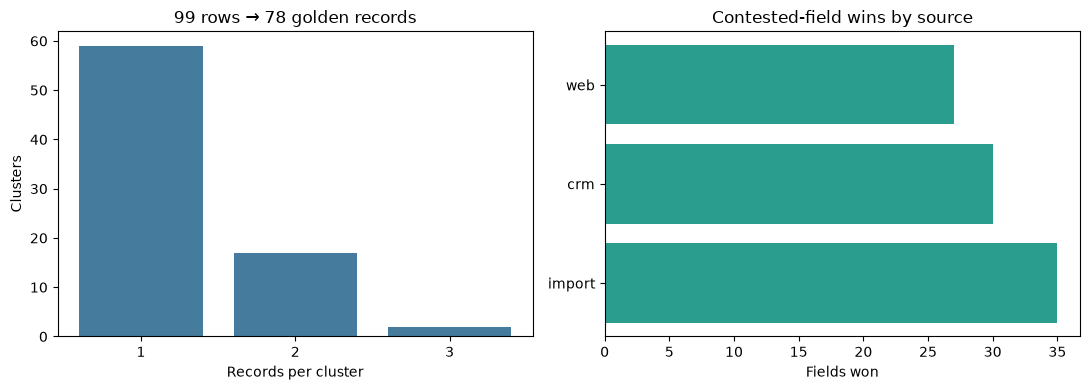

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
sizes = golden["cluster_size"].value_counts().sort_index()
ax1.bar(sizes.index.astype(str), sizes.values, color="#457b9d")
ax1.set_xlabel("Records per cluster")
ax1.set_ylabel("Clusters")
ax1.set_title(f"{report.input_rows} rows → {report.clusters} golden records")

wins = report.field_provenance["winning_source"].value_counts()
ax2.barh(wins.index, wins.values, color="#2a9d8f")
ax2.set_title("Contested-field wins by source")
ax2.set_xlabel("Fields won")

fig.tight_layout()
fig.savefig("dedup_results.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Stage | What it did |
|---|---|
| Normalize | Gmail dot/plus stripping, phone digit extraction — variants collide |
| Cluster | 99 rows → 78 entities (21 duplicates absorbed) |
| Survivorship | per-field rules, not row-level "keep newest" — each field gets its best value |
| Provenance | every contested field logged: winner, source, rule |

Row-level dedup ("keep the newest record") throws away the CRM's better email and the web's fresher phone. **Field-level survivorship keeps both.** That's the difference between deduplication and master data management.


## Try your own

In [6]:
# import pandas as pd
# my_df = pd.read_csv("customers.csv")   # needs: record_id, source, updated_at + data columns
# my_work = add_match_keys(my_df)
# my_rules = {
#     "email": source_priority(["salesforce", "shopify", "csv_import"]),
#     "address": longest_value,
# }
# my_golden, my_report = dedupe(my_work, ["email_norm"], my_rules)
# print(my_report.clusters, "golden records")
# my_report.field_provenance.head()

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
